In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

torch.manual_seed(42)

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(64, padding=4, padding_mode="reflect"),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = ImageFolder(
    "../data/train",
    transform=train_transforms
)

val_dataset = ImageFolder(
    "../data/val",
    transform=val_transforms
)

print(f"Length of train dataset: {len(train_dataset)}")
print(f"Length of validation dataset: {len(val_dataset)}")

Length of train dataset: 21600
Length of validation dataset: 2700


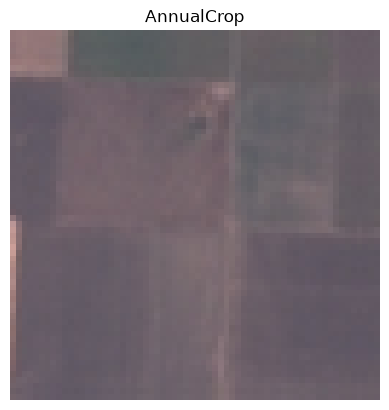

In [2]:
import matplotlib.pyplot as plt
image, label = train_dataset[0]

plt.imshow(image.permute(1, 2, 0))
plt.title(f"{train_dataset.classes[label]}")
plt.axis("off")
plt.show()

In [3]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=64,
    shuffle=False
)

In [4]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layer = nn.Sequential(
            # 3x64x64 -> 32x64x64
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),

            # 32x64x64 -> 64x64x64
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),

            # 64x64x64 -> 128x64x64
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),
            # 128x64x64 -> 128x32x32
            nn.MaxPool2d(kernel_size=2),

            # 128x32x32 -> 128x32x32
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),
            # 128x32x32 -> 128x16x16
            nn.MaxPool2d(kernel_size=2),

            # 128x16x16 -> 256x16x16
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            # 256x16x16 -> 256x8x8
            nn.MaxPool2d(kernel_size=2),

            # 256x8x8 -> 256x8x8
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            # 256x8x8 -> 256x4x4
            nn.MaxPool2d(kernel_size=2)
        )

        self.mlp = nn.Sequential(
            # 256x4x4 -> 4096
            nn.Flatten(),

            # 4096 -> 1024
            nn.Linear(in_features=256*4*4, out_features=1024),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # 1024 -> 256
            nn.Linear(in_features=1024, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # 256 -> 10
            nn.Linear(in_features=256, out_features=10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.mlp(x)

        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


In [5]:
model = CustomCNN().to(device)
model

CustomCNN(
  (conv_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128,

In [6]:
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall
)

train_acc_metric = MulticlassAccuracy(num_classes=10).to(device)
train_prec_metric = MulticlassPrecision(num_classes=10, average="macro").to(device)
train_rec_metric = MulticlassRecall(num_classes=10, average="macro").to(device)

val_acc_metric = MulticlassAccuracy(num_classes=10).to(device)
val_prec_metric = MulticlassPrecision(num_classes=10, average="macro").to(device)
val_rec_metric = MulticlassRecall(num_classes=10, average="macro").to(device)

In [7]:
from torch.optim import Adam

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(params=model.parameters(), lr=0.0005, weight_decay=1e-4)

In [8]:
import pandas as pd

results = []
epochs = 30

best_val_acc = 0

for epoch in range(epochs):
    history = {}
    train_running_loss = 0

    history["epoch"] = epoch + 1

    # Training Loop
    model.train()
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        output = model(images)

        loss = loss_fn(output, labels)
        train_running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_acc_metric.update(output, labels)
        train_prec_metric.update(output, labels)
        train_rec_metric.update(output, labels)

    train_loss = train_running_loss / len(train_dataloader)

    history["train_loss"] = train_loss
    history["train_acc"] = train_acc_metric.compute().item()
    history["train_prec"] = train_prec_metric.compute().item()
    history["train_rec"] = train_rec_metric.compute().item()

    train_acc_metric.reset()
    train_prec_metric.reset()
    train_rec_metric.reset()


    # Validation Loop
    model.eval()

    val_running_loss = 0

    with torch.inference_mode():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)

            output = model(images)

            loss = loss_fn(output, labels)
            val_running_loss += loss.item()

            val_acc_metric.update(output, labels)
            val_prec_metric.update(output, labels)
            val_rec_metric.update(output, labels)

        val_loss = val_running_loss / len(val_dataloader)

        history["val_loss"] = val_loss
        history["val_acc"] = val_acc_metric.compute().item()
        history["val_prec"] = val_prec_metric.compute().item()
        history["val_rec"] = val_rec_metric.compute().item()
    
        val_acc_metric.reset()
        val_prec_metric.reset()
        val_rec_metric.reset()

    print(f"Epoch {epoch + 1} :-")
    print(f"Train Loss: {history['train_loss']:.2f} | Train Acc: {history['train_acc']*100:.2f}% | Train Prec: {history['train_prec']*100:.2f}% | Train Rec: {history['train_rec']*100:.2f}%")
    print(f"Val Loss: {history['val_loss']:.2f} | Val Acc: {history['val_acc']*100:.2f}% | Val Prec: {history['val_prec']*100:.2f}% | Val Rec: {history['val_rec']*100:.2f}%")

    if(history['val_acc'] >= best_val_acc):
        best_val_acc = history['val_acc']
        torch.save(model.state_dict(), "../models/CustomCNNModel.pt")
        print(f"Best Model Saved!! Val Acc: {history['val_acc']*100:.2f}%")
    print("\n")
    results.append(history)

df = pd.DataFrame(results)

Epoch 1 :-
Train Loss: 0.92 | Train Acc: 66.42% | Train Prec: 65.88% | Train Rec: 66.42%
Val Loss: 0.67 | Val Acc: 74.04% | Val Prec: 78.17% | Val Rec: 74.04%
Best Model Saved!! Val Acc: 74.04%


Epoch 2 :-
Train Loss: 0.56 | Train Acc: 80.33% | Train Prec: 80.18% | Train Rec: 80.33%
Val Loss: 0.59 | Val Acc: 78.10% | Val Prec: 84.56% | Val Rec: 78.10%
Best Model Saved!! Val Acc: 78.10%


Epoch 3 :-
Train Loss: 0.41 | Train Acc: 86.11% | Train Prec: 86.08% | Train Rec: 86.11%
Val Loss: 0.25 | Val Acc: 92.12% | Val Prec: 91.93% | Val Rec: 92.12%
Best Model Saved!! Val Acc: 92.12%


Epoch 4 :-
Train Loss: 0.31 | Train Acc: 89.14% | Train Prec: 89.13% | Train Rec: 89.14%
Val Loss: 1.07 | Val Acc: 67.38% | Val Prec: 75.71% | Val Rec: 67.38%


Epoch 5 :-
Train Loss: 0.29 | Train Acc: 90.33% | Train Prec: 90.33% | Train Rec: 90.33%
Val Loss: 0.26 | Val Acc: 90.40% | Val Prec: 92.05% | Val Rec: 90.40%


Epoch 6 :-
Train Loss: 0.27 | Train Acc: 90.82% | Train Prec: 90.84% | Train Rec: 90.82%
V

In [9]:
import matplotlib.pyplot as plt

def plot_metric(x, y1, y2, metric):
    xlabel = df[x]
    y1label = df[y1]
    y2label = df[y2]

    plt.title(f"Train v/s Validation {metric}")

    plt.plot(xlabel, y1label, label=f"Training {metric}")
    plt.plot(xlabel, y2label, label=f"Validation {metric}")

    plt.xlabel("Epochs")
    plt.ylabel(f"{metric}")

    plt.tight_layout()
    plt.show()

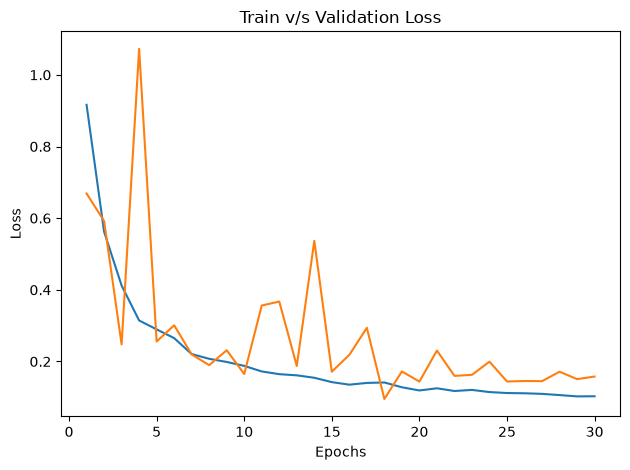

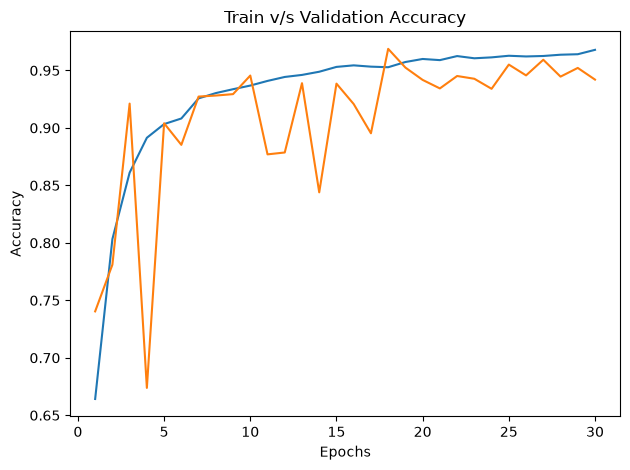

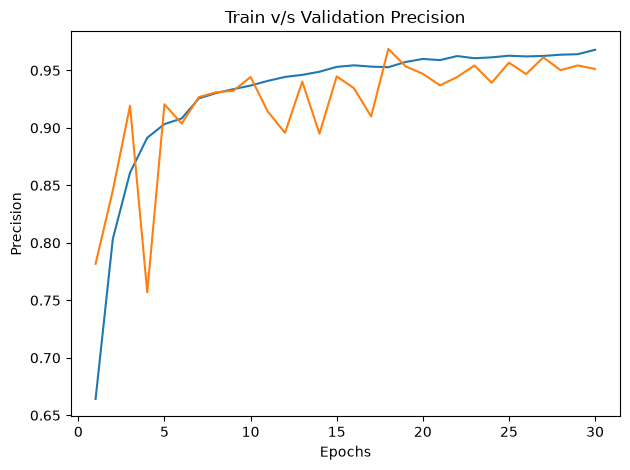

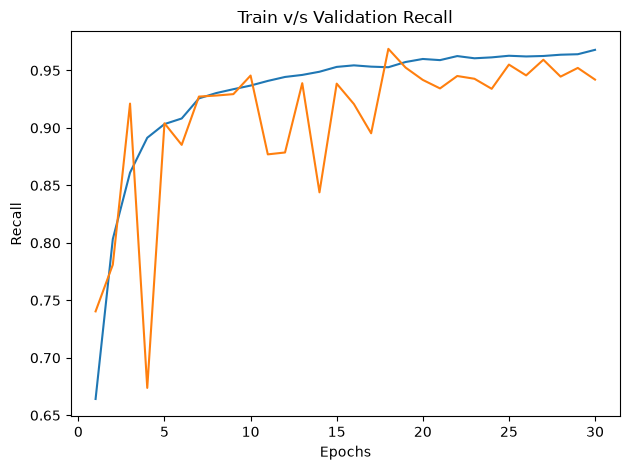

In [10]:
plot_metric('epoch', 'train_loss', 'val_loss', 'Loss')
plot_metric('epoch', 'train_acc', 'val_acc', 'Accuracy')
plot_metric('epoch', 'train_rec', 'val_prec', 'Precision')
plot_metric('epoch', 'train_rec', 'val_rec', 'Recall')